In [12]:
import tensorflow as tf
import tensorflow_probability as tfp
import numpy as np
tfd = tfp.distributions
tfb = tfp.bijectors
vi  = tfp.experimental.vi
from bakeoff.TensorFlow_Prob.run_tfp import make_conditioned_lp
from tqdm.notebook import tqdm

from modulars.distributions import gaussian_multid, gaussian_multid_posterior, ensure_arr
from modulars.utils import check_all_int_or_float_or_1darrays, check_all_covar_shaped_arrays
from modulars.tfp_rr_test import tfp_run_restart_multid

In [13]:
# this is 40 dimensions
mu_prior = np.zeros(40)
sigma_prior = np.ones(40) * 10 # diag std of prior
mu_like = 2.0
sigma_like = 1.0 # std of likelihood
max_iters = 200_000
n_obs = 3
dim = 40
np.random.seed(42)

DIAG = True

# Generate observations for each dimension
observed_data = gaussian_multid(
    seed=42, n_samples=n_obs, mu_like=mu_like,
    scale_like=sigma_like, dim=dim)
# compute known posterior, this is the posterior diagonal standard deviation vector as true_sigma_post
true_mu_post, true_sigma_post = gaussian_multid_posterior(
    observed_data, n_samples=n_obs,
    mu_prior=mu_prior, scale_prior=sigma_prior**2,
    scale_like=1.0, std_devs=False,
    diag=DIAG, dim=40)

In [14]:
# we need to represent the covariance as a lower triangular
# matrix for tfp's MultiVariateNormalTriL distribution
# this is not a problem for a diagonal case.

In [15]:
if DIAG:
    print("Running diagonal covariance case")
    # this runs the easiest case where all dimensions are i.i.d.
    # note that this assumes the inputs are standard deviations!
    # only run this cell if diag is True and all of the parameters are floats or 1d arrays
    assert DIAG, "this code only works for diagonal covariance matrices"
    assert check_all_int_or_float_or_1darrays(mu_prior, sigma_prior, mu_like, sigma_like), "all parameters must be floats or 1d arrays"

    prior_scale_tril = np.eye(40) * sigma_prior          # not np.sqrt(sigma_prior)
    like_scale_tril  = np.eye(40) * sigma_like          # not np.sqrt(sigma_likelihoods)
    # since these are tri-lower matrices, the diagonal entries are the standard deviations, not the variances.

    conditioned_log_prob = make_conditioned_lp(
        prior_dist=tfd.MultivariateNormalTriL(
            loc=tf.cast(mu_prior, tf.float32),
            scale_tril=tf.cast(prior_scale_tril, tf.float32),
        ),
        likelihood_dist=lambda z: tfd.MultivariateNormalTriL(
            loc=z,
            scale_tril=tf.cast(like_scale_tril, tf.float32),
        ),
        x=tf.cast(observed_data, tf.float32),
        multivar=True,
    )

Running diagonal covariance case


In [16]:
if not DIAG:
    print ("Running non-diagonal covariance case")
    # this is if we have non-diagonal covariance matrices,
    # which means that we need the full covariance matrices
    # inputs should be 2d arrays of shape (dim, dim)
    assert check_all_covar_shaped_arrays(dim, sigma_prior, sigma_like), "must input correctly shaped ({dim}, {dim})covariance matrices"
    
    # need to turn the full covariance matrices into
    # lower triangular matrices using cholesky decomp C = LL^T
    prior_scale_tril = np.linalg.cholesky(sigma_prior)
    like_scale_tril  = np.linalg.cholesky(sigma_like)

    conditioned_log_prob = make_conditioned_lp(
        prior_dist=tfd.MultivariateNormalTriL(
            loc=tf.cast(mu_prior, tf.float32),
            scale_tril=tf.cast(prior_scale_tril, tf.float32),
        ),
        likelihood_dist=lambda z: tfd.MultivariateNormalTriL(
            loc=z,
            scale_tril=tf.cast(like_scale_tril, tf.float32),
        ),
        x=tf.cast(observed_data, tf.float32),
        multivar=True,
    )

In [17]:
results = []
for seed in tqdm(range(25)):
    result = tfp_run_restart_multid(
        seed, dim, 
        conditioned_log_prob,
        n_iters=100_000
    )
    results.append(result)

  0%|          | 0/25 [00:00<?, ?it/s]

In [18]:
%matplotlib inline
from modulars.utils import apply_traj_transform_multid
single_means, single_stds, multi_means, multi_stds = \
    apply_traj_transform_multid(results, TFP=True)

  0%|          | 0/25 [00:00<?, ?it/s]

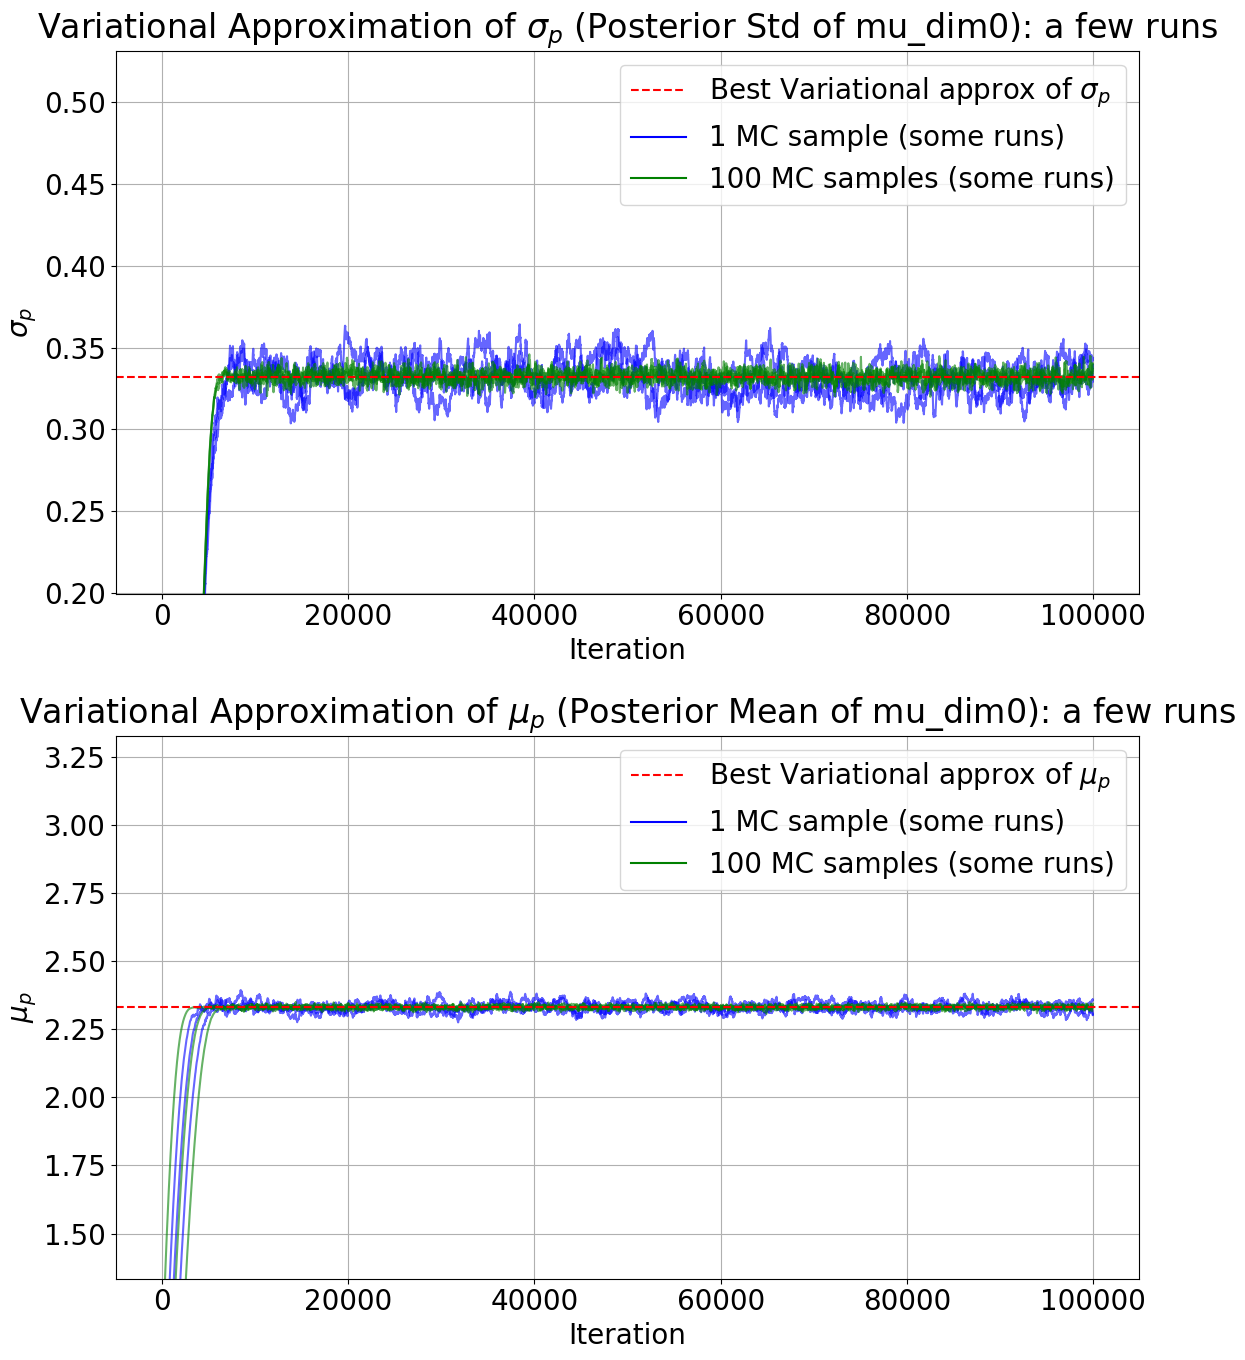

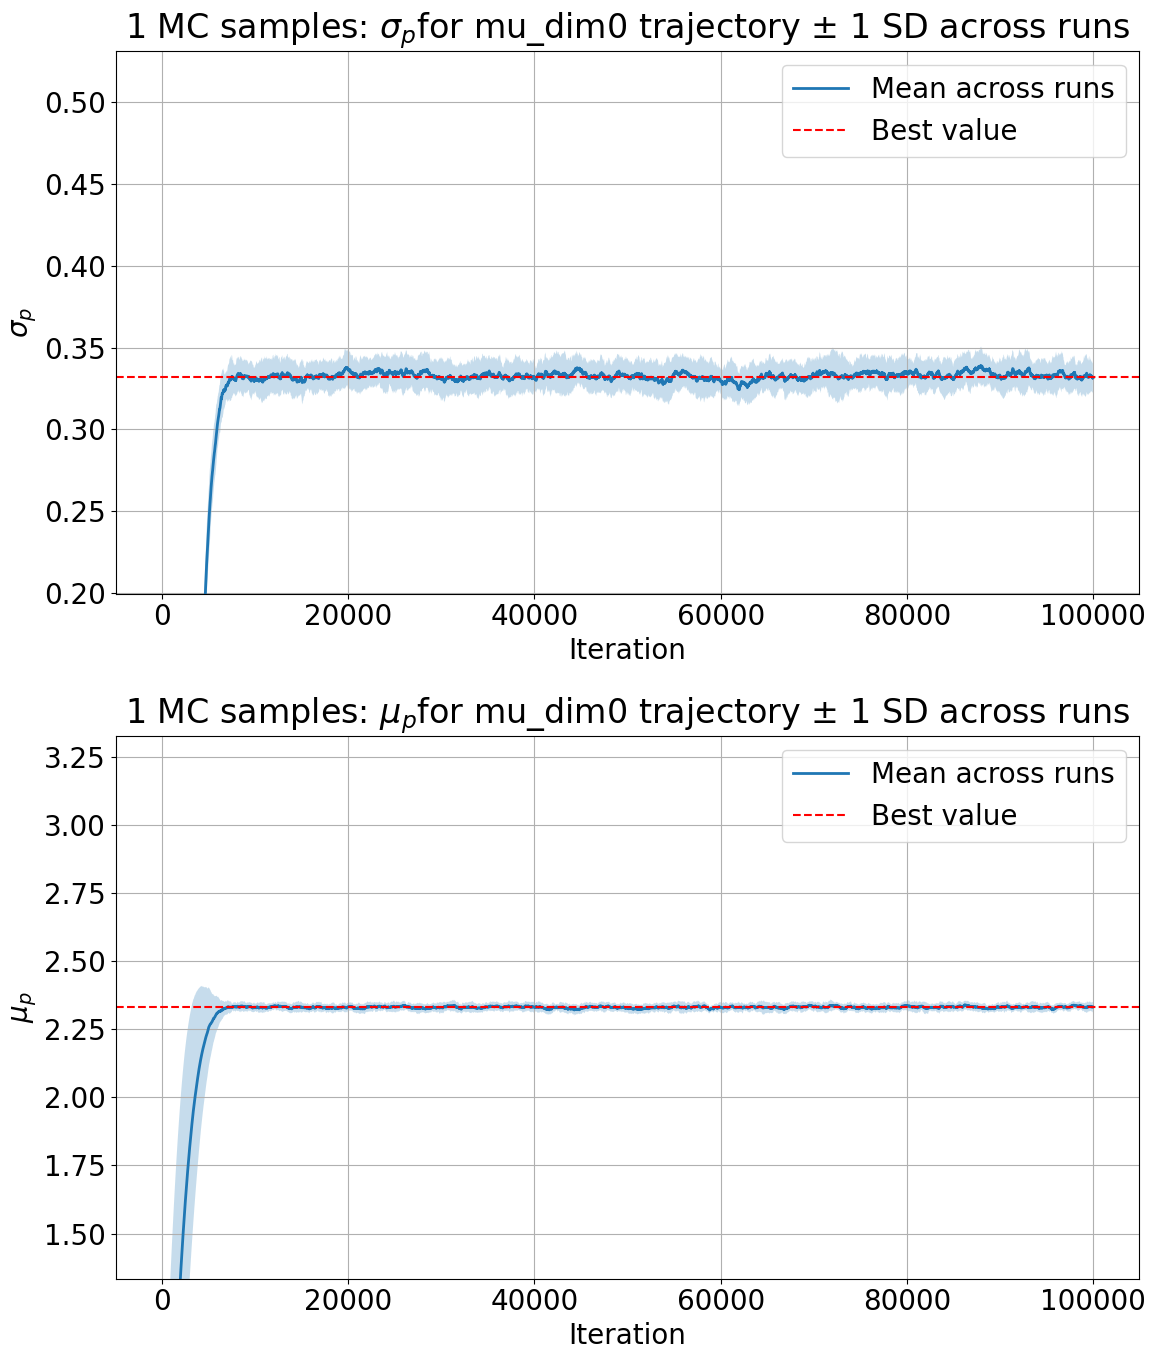

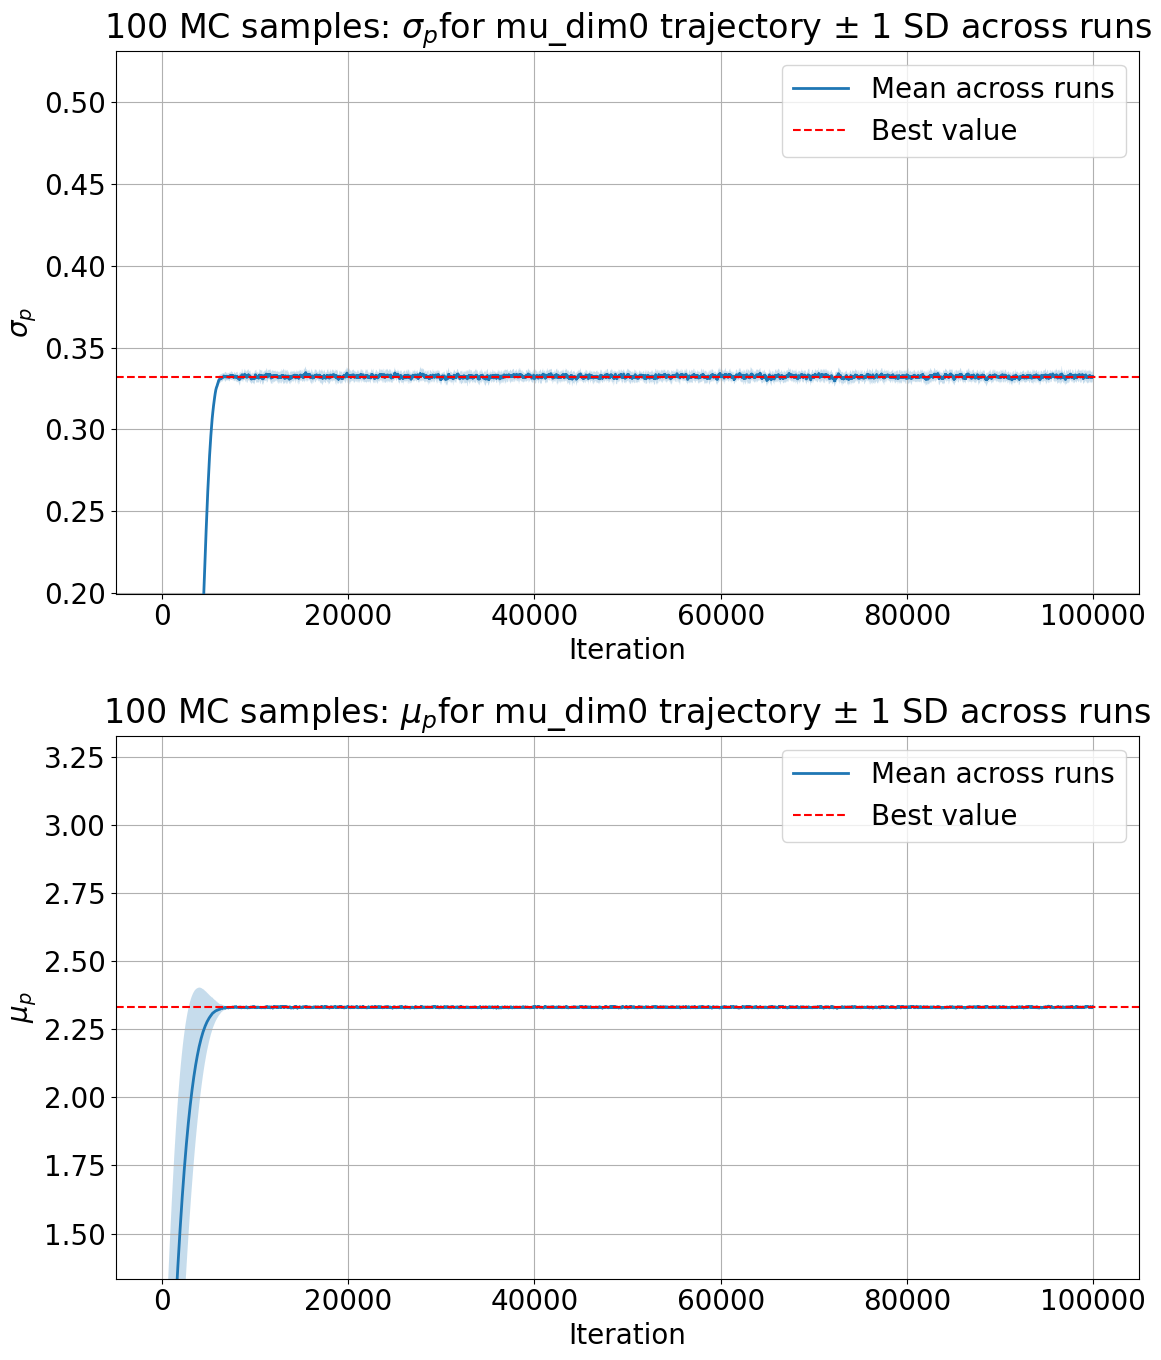

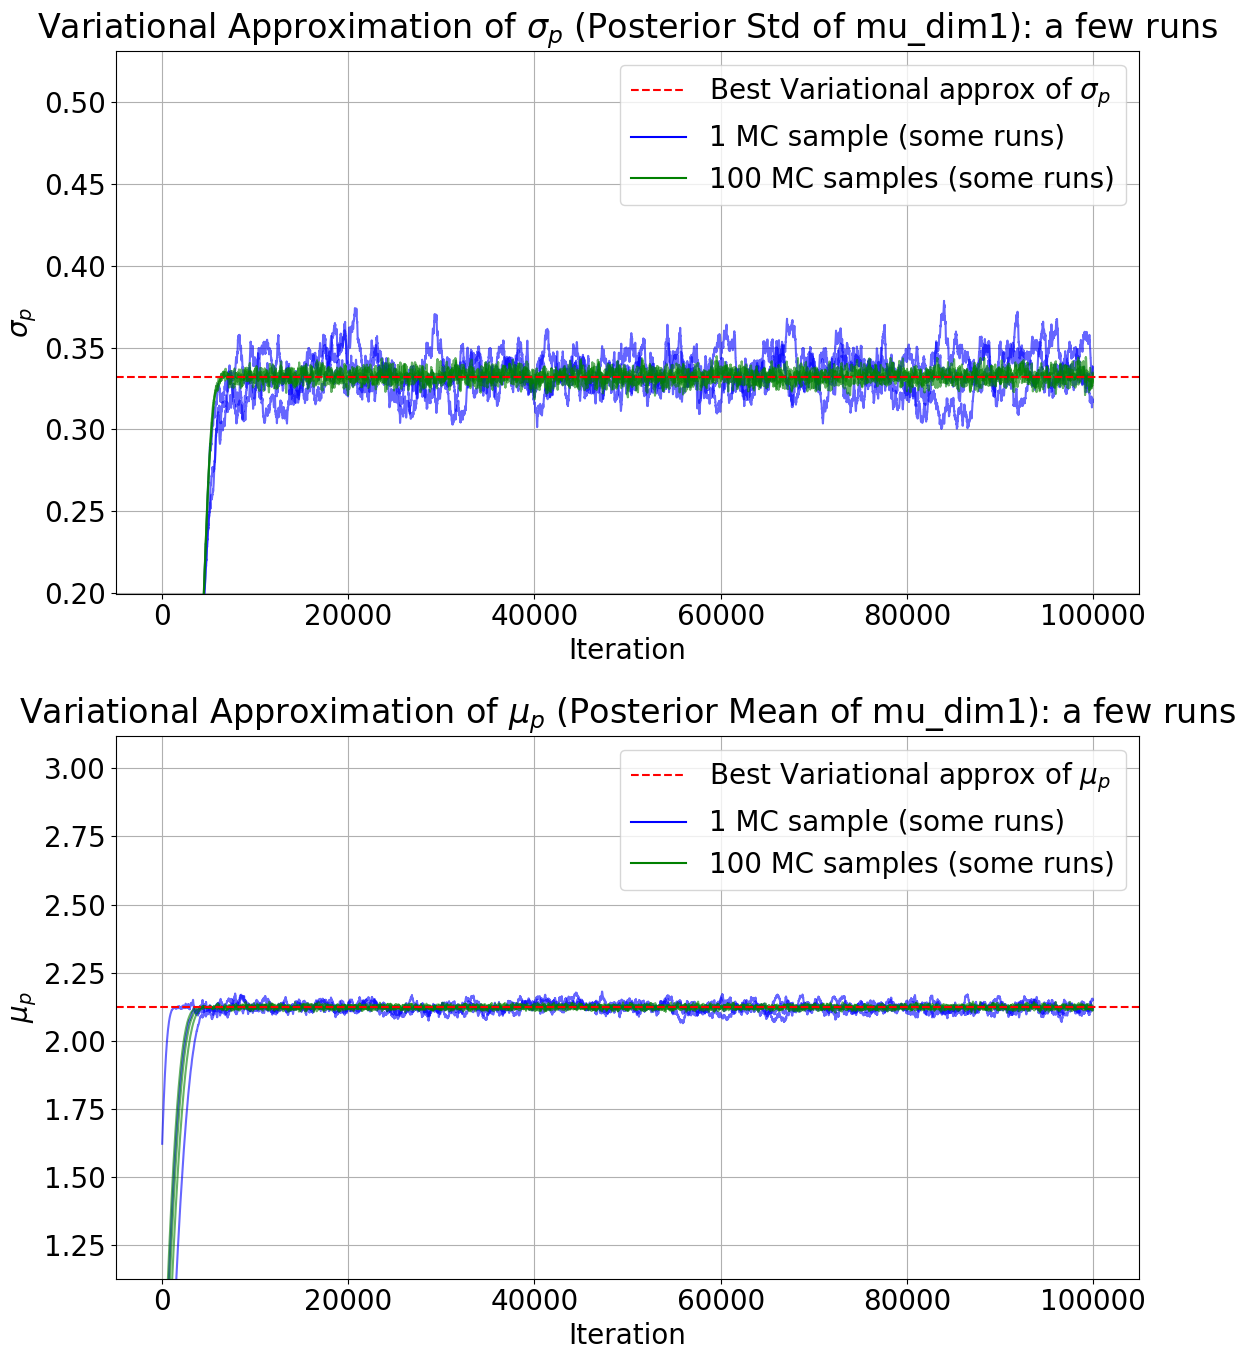

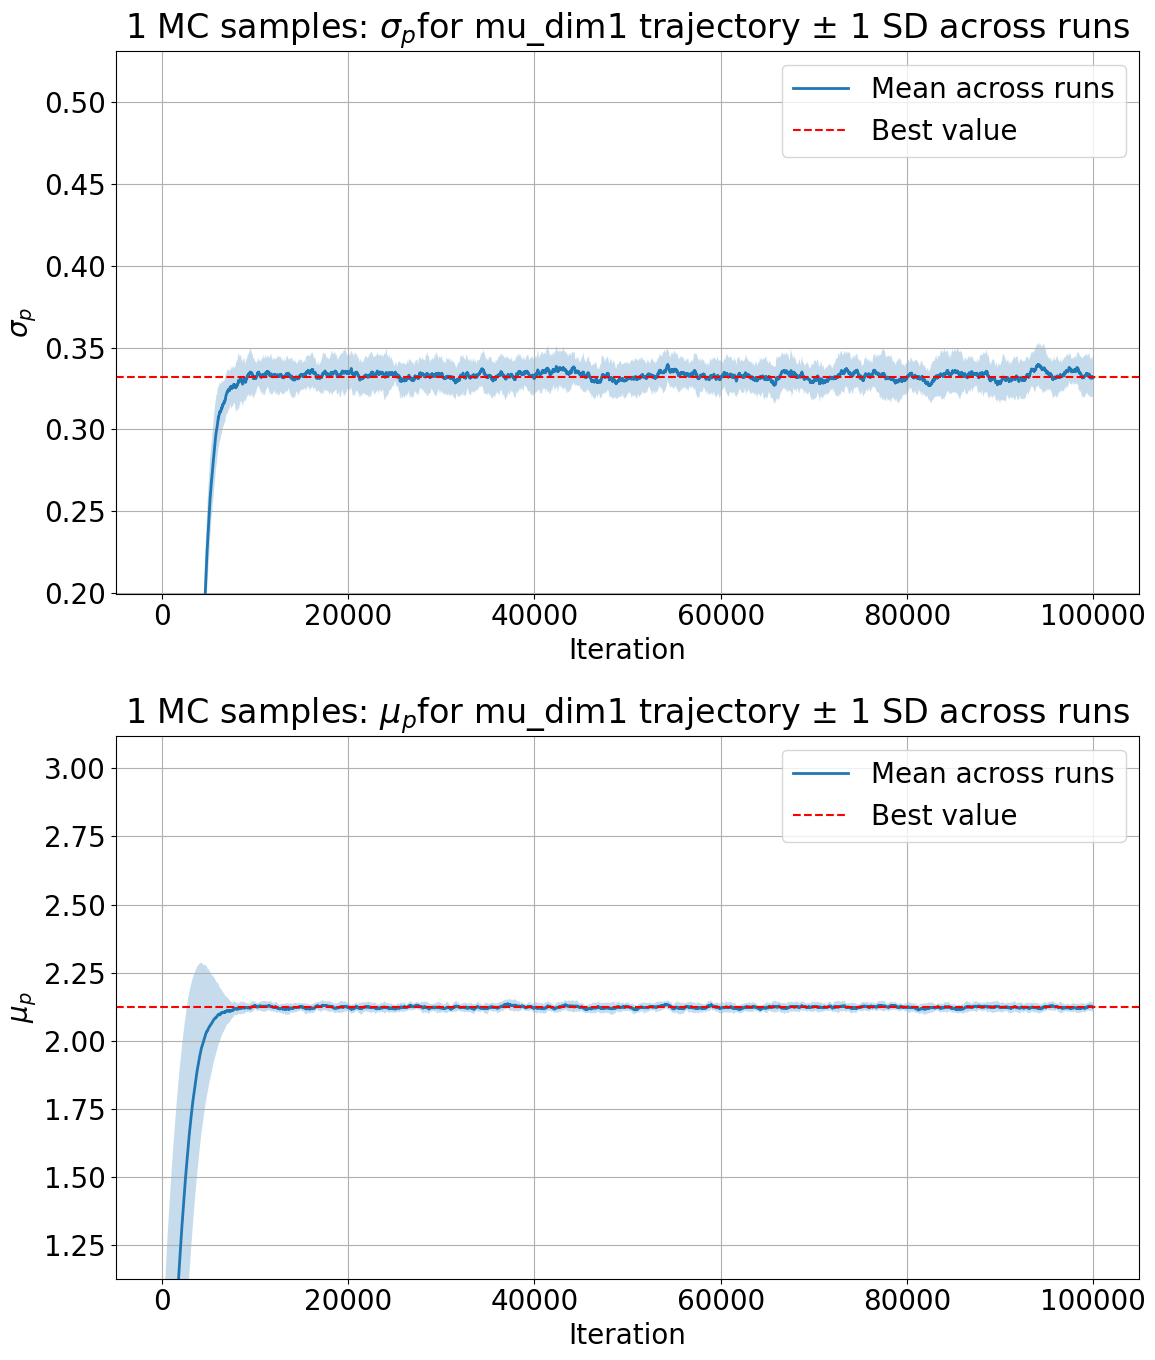

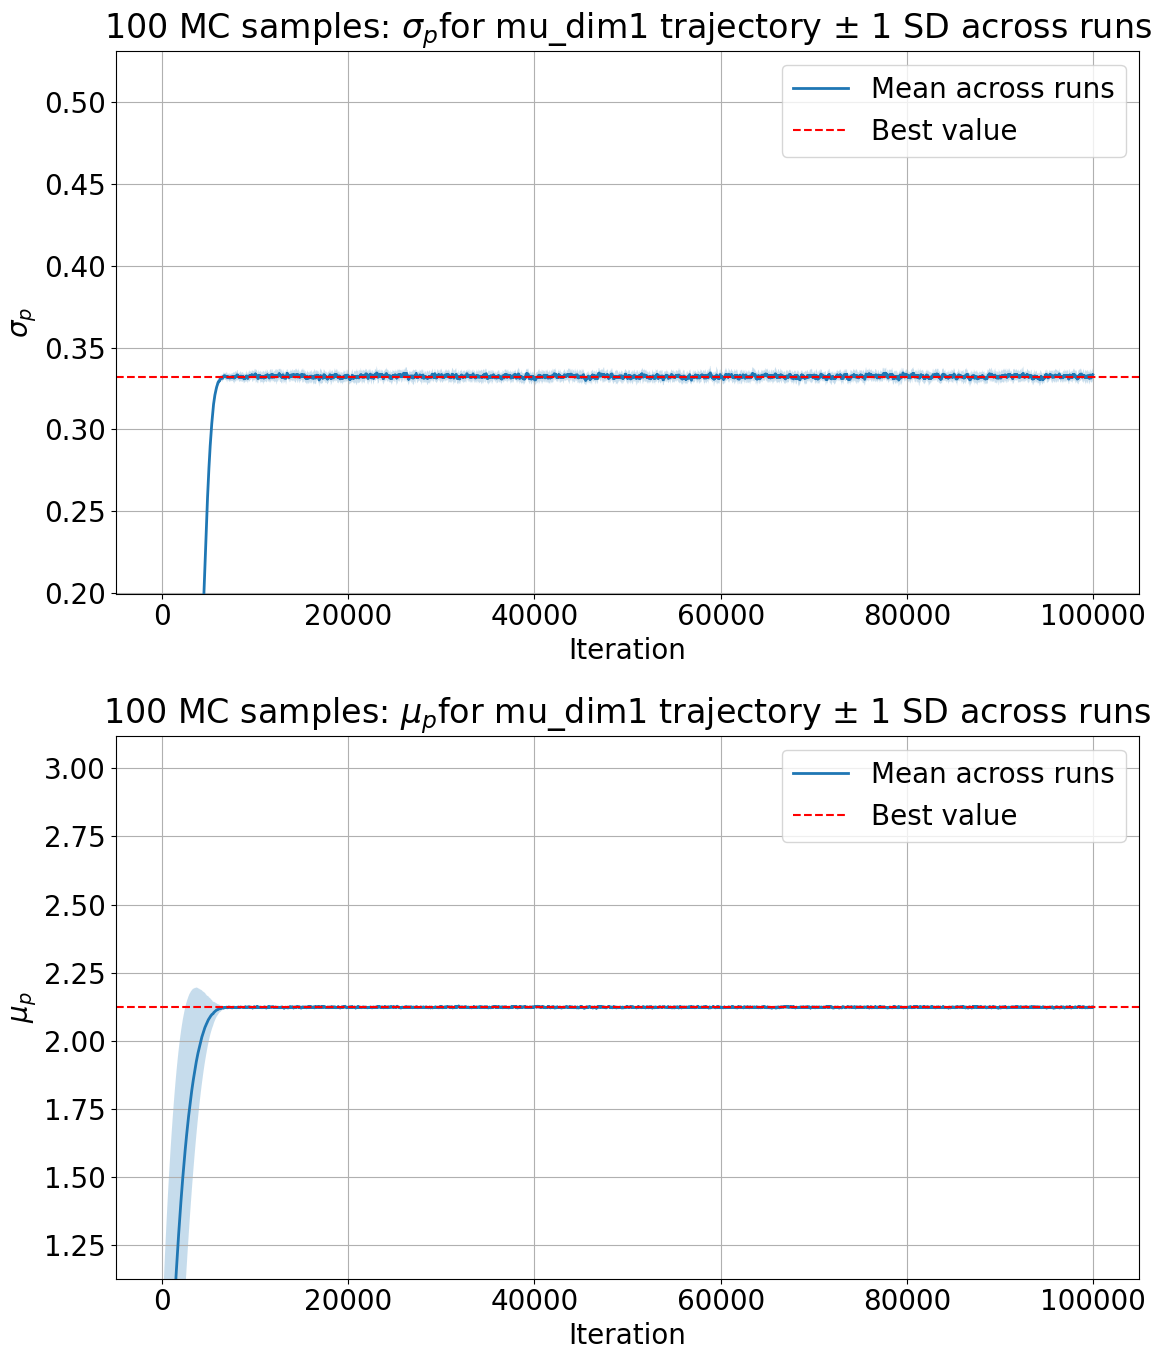

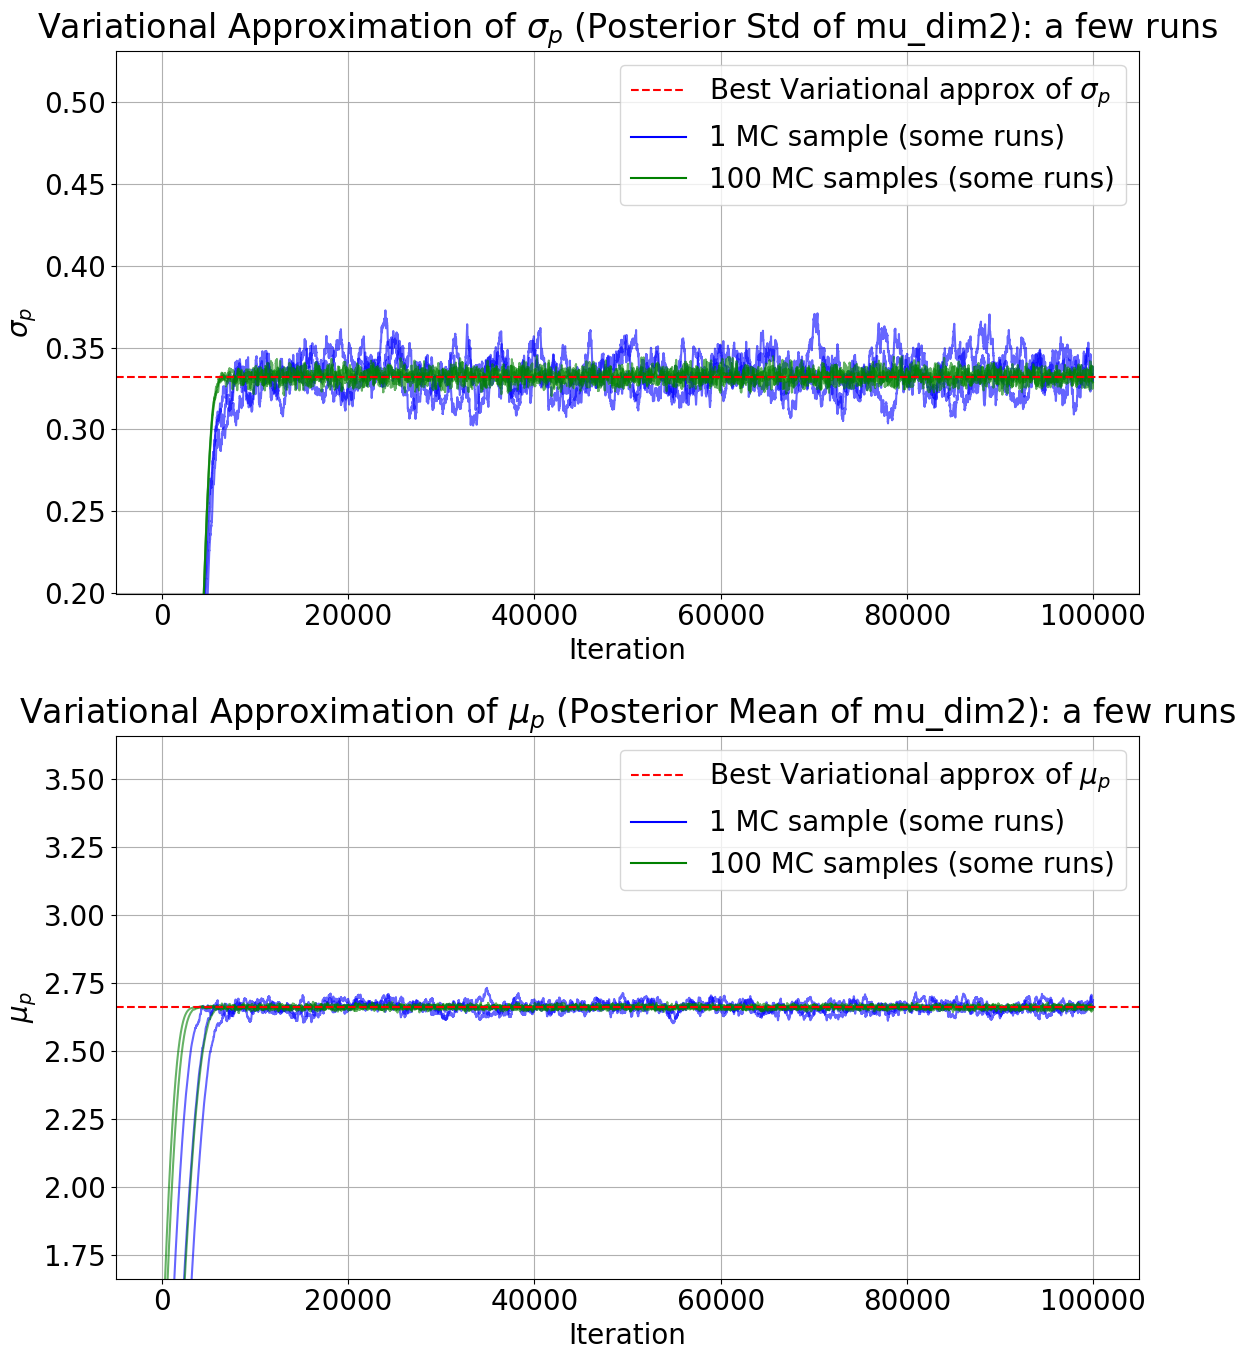

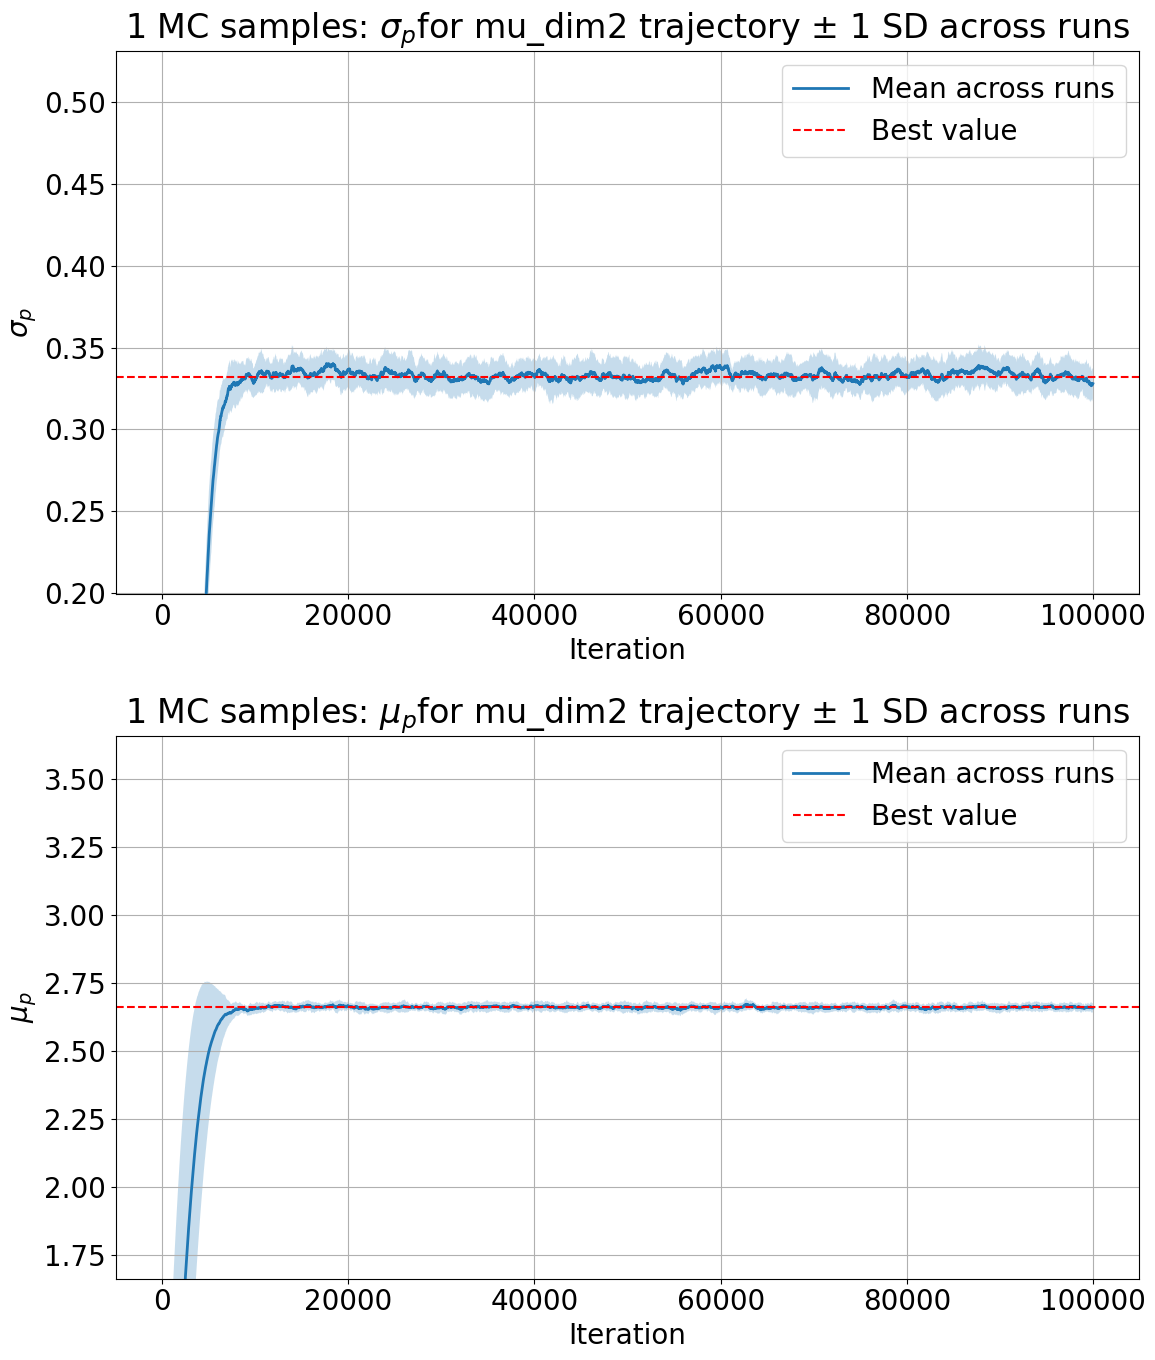

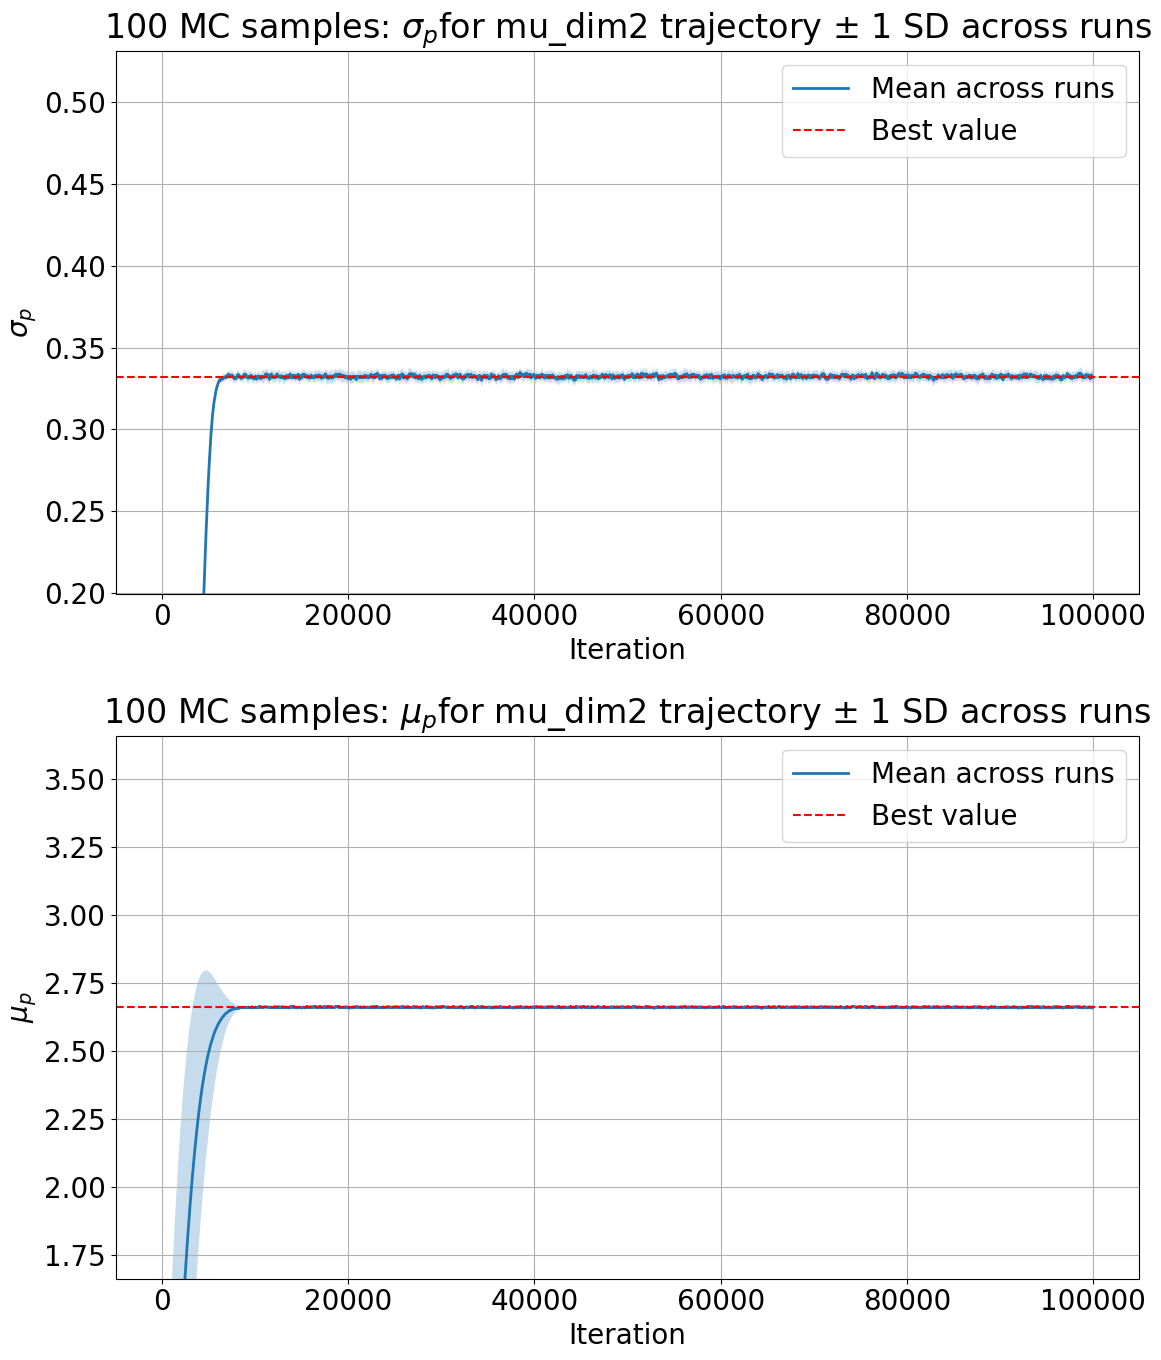

In [19]:

from modulars.plot_rr import plot_some_dims_multid
which_dims = [0, 1, 2]
plot_some_dims_multid(
    single_means, single_stds, multi_means, multi_stds,
    true_mu_post, true_sigma_post, 'mu', dim,
    which_dims, k=3
)